# FASE 2B: AutoML Benchmark (FLAML)

**Proyecto Integrador — Grupo 2:** Analisis de Satisfaccion en Productos de Oficina
**Objetivo:** AutoML con FLAML - clasificacion con optimizacion de hiperparametros



In [16]:
!pip install "flaml[automl]" -q
!pip install mlflow catboost -q


## Configuración del Entorno

In [17]:
import os
import sys
import gc
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import mlflow

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score
from flaml import AutoML

import lightgbm as lgb
from scipy.sparse import hstack, csr_matrix

from tqdm.auto import tqdm

RANDOM_SEED = 42

FEATURE_COLS = ['mayusculas_count', 'char_total', 'exclamacion_count',
                'interrogacion_count', 'porcentaje_mayusculas',
                'puntuacion_emocional', 'total_tokens', 'unique_types', 'ttr']



In [18]:
IN_COLAB = 'google.colab' in sys.modules

TOTAL_MEMORY = 0

try:
    import psutil
    TOTAL_MEMORY = psutil.virtual_memory().total
except ImportError:
    pass

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = Path('/content/drive/MyDrive/ML/proyecto_integrador')
else:
    BASE = Path('..')

DATA_DIR = BASE / 'data'
REPORTS_DIR = BASE / 'reports'
MODELS_DIR = BASE / 'models'
DATA_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

MLFLOW_TRACKING_URI = os.environ.get('MLFLOW_TRACKING_URI', 'https://humorous-trusting-domelike.ngrok-free.dev')
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment('f2b_automl_flaml')

print(f"=== Environment Info ===")
print(f"IN_COLAB: {IN_COLAB}")
if TOTAL_MEMORY:
    print(f"System RAM: {TOTAL_MEMORY / (1024**3):.1f} GB")
print(f"BASE: {BASE}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"MLFLOW_TRACKING_URI: {MLFLOW_TRACKING_URI}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
=== Environment Info ===
IN_COLAB: True
System RAM: 12.7 GB
BASE: /content/drive/MyDrive/ML/proyecto_integrador
DATA_DIR: /content/drive/MyDrive/ML/proyecto_integrador/data
MLFLOW_TRACKING_URI: https://humorous-trusting-domelike.ngrok-free.dev


## Carga de Datos

Dataset canónico desde `f1_eda_definitivo`. Se mapea `target_class` (Negativo/Neutro/Positivo) a valores numéricos con LabelEncoder.

In [19]:
print('Cargando dataset canonico desde f1_eda_definitivo...')
CANONICAL_PATH = DATA_DIR / 'office_products_balanced.parquet'

try:
    df = pd.read_parquet(CANONICAL_PATH, columns=['text', 'target_class'] + FEATURE_COLS)
except FileNotFoundError:
    print(f'[ERROR] Dataset canonico no encontrado en {CANONICAL_PATH}')
    print('Ejecute primero f1_eda_definitivo.ipynb en Colab para generarlo.')
    raise
except Exception as e:
    print(f'[ERROR] No se pudo cargar el dataset: {e}')
    raise

label_encoder = LabelEncoder()
df['target'] = label_encoder.fit_transform(df['target_class'])
print('Mapeo de clases:', dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# word_count filter
df['word_count'] = df['text'].astype(str).str.split().str.len()
df = df[df['word_count'] >= 5]
print(f'Registros tras filtro word_count >= 5: {len(df):,}')

print('\nDistribucion de target (0=Negativo, 1=Neutro, 2=Positivo):')
print(df['target'].value_counts().sort_index())

SUBSAMPLE_SIZE = 1_000_000
print(f'\nSubmuestreo estratificado a {SUBSAMPLE_SIZE:,} filas...')
df, _ = train_test_split(
    df, train_size=SUBSAMPLE_SIZE, random_state=RANDOM_SEED, stratify=df['target']
)
print(f'Dataset reducido a {len(df):,} filas')
print(df['target'].value_counts().sort_index())

Cargando dataset canonico desde f1_eda_definitivo...
Mapeo de clases: {'Negativo': np.int64(0), 'Neutro': np.int64(1), 'Positivo': np.int64(2)}
Registros tras filtro word_count >= 5: 2,498,299

Distribucion de target (0=Negativo, 1=Neutro, 2=Positivo):
target
0    999635
1    499857
2    998807
Name: count, dtype: int64

Submuestreo estratificado a 1,000,000 filas...
Dataset reducido a 1,000,000 filas
target
0    400126
1    200079
2    399795
Name: count, dtype: int64


## Submuestreo Estratificado

Para equilibrar costo computacional y representatividad, se toma una muestra estratificada de ~200K filas (~66.6K por clase).


In [20]:
SAMPLE_SIZE = 200000
print(f'Submuestreo estratificado a {SAMPLE_SIZE} filas...')

df_sample = df.groupby('target', group_keys=False, as_index=False).apply(
    lambda x: x.sample(n=min(SAMPLE_SIZE // 3, len(x)), random_state=RANDOM_SEED)
).reset_index(drop=True)

print(f'Muestra estratificada: {len(df_sample):,} filas')
print(df_sample['target'].value_counts().sort_index())

del df
gc.collect()

Submuestreo estratificado a 200000 filas...


/tmp/ipykernel_6805/2168598534.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_sample = df.groupby('target', group_keys=False, as_index=False).apply(


Muestra estratificada: 199,998 filas
target
0    66666
1    66666
2    66666
Name: count, dtype: int64


17

## División Train/Test

Se divide ANTES de vectorizar para prevenir Data Leakage. El vocabulario de test no debe contaminar el vectorizador.

In [21]:
print('Dividiendo en Train/Test (80/20)...')
X_train_text, X_test_text, X_train_feats, X_test_feats, y_train, y_test = train_test_split(
    df_sample['text'], df_sample[FEATURE_COLS], df_sample['target'],
    test_size=0.2, random_state=RANDOM_SEED, stratify=df_sample['target']
)

del df_sample
gc.collect()

print(f'Train: {len(X_train_text):,} | Test: {len(X_test_text):,}')

Dividiendo en Train/Test (80/20)...
Train: 159,998 | Test: 40,000


## Vectorización TF-IDF

Se ajusta el vectorizador solo sobre Train. Test solo se transforma.

In [22]:
print('Vectorizando con TF-IDF...')
vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words='english',
    ngram_range=(1, 2),
    min_df=5
)

X_train_tfidf = vectorizer.fit_transform(X_train_text.astype(str))
X_test_tfidf = vectorizer.transform(X_test_text.astype(str))

print('Concatenando TF-IDF con features engineered...')
X_train = hstack([X_train_tfidf, csr_matrix(X_train_feats.values)])
X_test = hstack([X_test_tfidf, csr_matrix(X_test_feats.values)])

print(f'Matriz TF-IDF: Train {X_train.shape} | Test {X_test.shape}')
del X_train_tfidf, X_test_tfidf
gc.collect()

joblib.dump(vectorizer, MODELS_DIR / 'tfidf_vectorizer_flaml.joblib')
print(f'Vectorizer guardado en {MODELS_DIR / "tfidf_vectorizer_flaml.joblib"}')

Vectorizando con TF-IDF...
Concatenando TF-IDF con features engineered...
Matriz TF-IDF: Train (159998, 10009) | Test (40000, 10009)
Vectorizer guardado en /content/drive/MyDrive/ML/proyecto_integrador/models/tfidf_vectorizer_flaml.joblib


## FLAML AutoML

FLAML (Microsoft) ejecuta AutoML con busqueda de hiperparametros sobre los datos de entrenamiento. Optimiza la metrica F1-macro con un time_budget de 10 minutos.


In [23]:
import time as _t
print('Ejecutando FLAML AutoML (time_budget=600s)...')
_t0 = _t.time()

automl = AutoML()
automl_settings = {
    'time_budget': 600,
    'metric': 'macro_f1',
    'task': 'classification',
    'estimator_list': ['lgbm', 'xgboost', 'rf', 'extra_tree', 'catboost'],
    'log_file_name': None,
    'seed': RANDOM_SEED,
    'n_jobs': -1,
    'eval_method': 'holdout',
    'retrain_full': True,
}

automl.fit(X_train, y_train, **automl_settings)
flaml_time = _t.time() - _t0

y_pred = automl.predict(X_test)
test_f1 = f1_score(y_test, y_pred, average='macro')

best_model_name = automl.best_estimator
# FLAML minimiza 1 - metric, asique best_loss = 1 - macro_f1
best_f1 = round(1 - automl.best_loss, 4)
test_f1 = round(test_f1, 4)

print(f'Tiempo: {flaml_time:.1f}s')
print(f'Mejor modelo: {best_model_name}')
print(f'FLAML F1-macro (validacion interna): {best_f1}')
print(f'FLAML F1-macro (test 10K): {test_f1}')

joblib.dump(automl.model.estimator, MODELS_DIR / 'flaml_best_model.joblib')
print(f'Modelo guardado en {MODELS_DIR / "flaml_best_model.joblib"}')

with mlflow.start_run(run_name='flaml_automl'):
    mlflow.set_tag('model_type', 'flaml_automl')
    mlflow.log_param('time_budget', 600)
    mlflow.log_param('best_estimator', best_model_name)
    mlflow.log_param('estimator_list', ','.join(automl_settings['estimator_list']))
    mlflow.log_metric('f1_macro_test', test_f1)
    mlflow.log_metric('f1_macro_val', best_f1)
    mlflow.log_metric('training_time_sec', flaml_time)

gc.collect()

Ejecutando FLAML AutoML (time_budget=600s)...
[flaml.automl.logger: 06-13 22:01:41] {2375} INFO - task = classification
[flaml.automl.logger: 06-13 22:01:41] {2386} INFO - Evaluation method: holdout
[flaml.automl.logger: 06-13 22:01:41] {2489} INFO - Minimizing error metric: 1-macro_f1
[flaml.automl.logger: 06-13 22:01:41] {2606} INFO - List of ML learners in AutoML Run: ['lgbm', 'xgboost', 'rf', 'extra_tree', 'catboost']
[flaml.automl.logger: 06-13 22:01:42] {2911} INFO - iteration 0, current learner lgbm
[flaml.automl.logger: 06-13 22:01:42] {3046} INFO - Estimated sufficient time budget=75633s. Estimated necessary time budget=163s.
[flaml.automl.logger: 06-13 22:01:42] {3097} INFO -  at 0.7s,	estimator lgbm's best error=5.6456e-01,	best estimator lgbm's best error=5.6456e-01
[flaml.automl.logger: 06-13 22:01:42] {2911} INFO - iteration 1, current learner lgbm
[flaml.automl.logger: 06-13 22:01:43] {3097} INFO -  at 1.2s,	estimator lgbm's best error=5.6456e-01,	best estimator lgbm's b

222

## Resultados

Leaderboard de FLAML, importancia de caracteristicas y matriz de confusion.


Leaderboard guardado en /content/drive/MyDrive/ML/proyecto_integrador/reports/flaml_leaderboard.csv


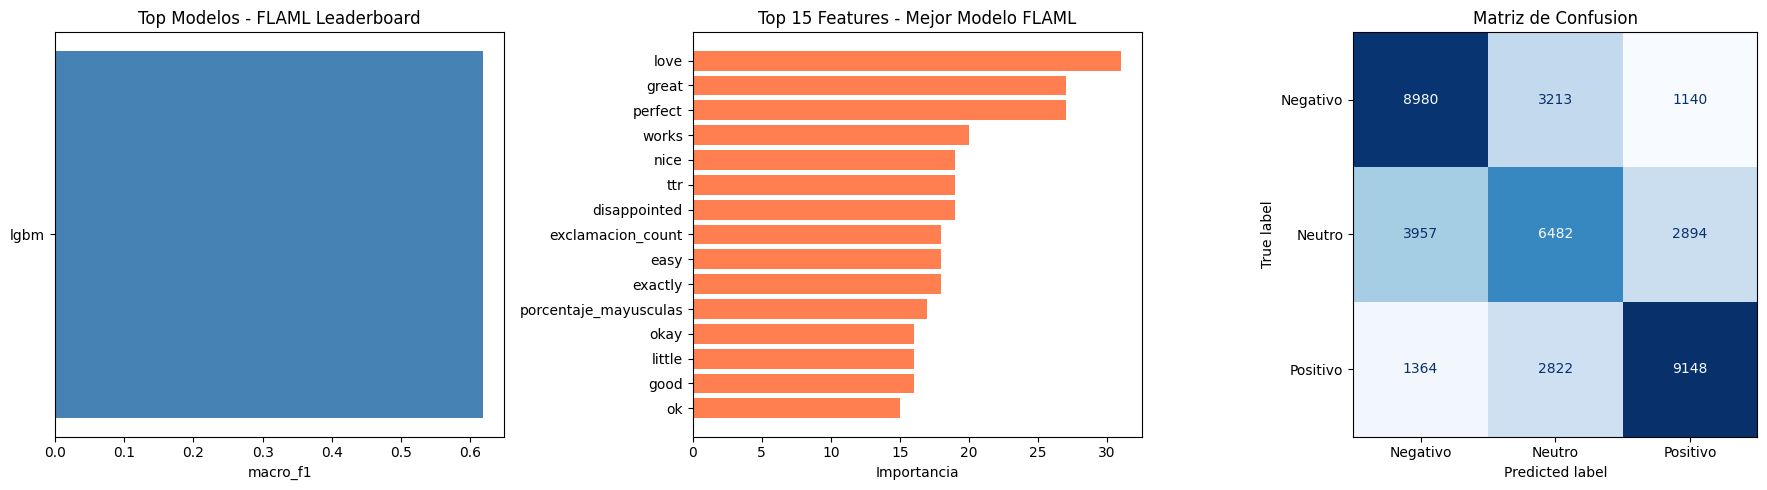

In [24]:
# Leaderboard
# The 'AutoML' object does not have a 'leaderboard' method.
# We will create a simplified leaderboard with the best model found.
# For a comprehensive leaderboard, set 'log_file_name' in automl_settings and parse the log file.
lb = pd.DataFrame({
    'estimator': [best_model_name],
    'macro_f1': [best_f1],
    'time_to_fit': [flaml_time] # Total time, as a proxy for the best model's training time in a simplified view
})
lb_path = REPORTS_DIR / 'flaml_leaderboard.csv'
lb.to_csv(lb_path, index=False)
print('Leaderboard guardado en', lb_path)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Leaderboard bar chart
top_lb = lb.head(8).copy()
if not top_lb.empty:
    metric_col = 'macro_f1'
    if metric_col not in top_lb.columns:
        numeric_cols = [c for c in top_lb.columns
                       if pd.api.types.is_numeric_dtype(top_lb[c])
                       and c not in ('best_loss',)]
        metric_col = numeric_cols[0] if numeric_cols else top_lb.columns[-1]

    top_lb = top_lb.sort_values(metric_col)
    axes[0].barh(range(len(top_lb)), top_lb[metric_col].values, color='steelblue')
    axes[0].set_yticks(range(len(top_lb)))
    axes[0].set_yticklabels(top_lb['estimator'].values)
    axes[0].set_xlabel(f'{metric_col}')
    axes[0].set_title('Top Modelos - FLAML Leaderboard')
    axes[0].invert_yaxis()

# 2. Feature importance
model = automl.model.estimator
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
elif hasattr(model, 'coef_'):
    coef = model.coef_
    importances = np.abs(coef).mean(axis=0) if coef.ndim > 1 else np.abs(coef)
else:
    importances = None

if importances is not None:
    feat_names = list(vectorizer.get_feature_names_out()) + FEATURE_COLS
    feat_df = pd.DataFrame({'feature': feat_names, 'importance': importances})
    top_feat = feat_df.sort_values('importance', ascending=False).head(15)
    axes[1].barh(range(len(top_feat)), top_feat['importance'].values, color='coral')
    axes[1].set_yticks(range(len(top_feat)))
    axes[1].set_yticklabels(top_feat['feature'].values)
    axes[1].set_xlabel('Importancia')
    axes[1].set_title('Top 15 Features - Mejor Modelo FLAML')
    axes[1].invert_yaxis()

# 3. Confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Negativo', 'Neutro', 'Positivo'],
    ax=axes[2], cmap='Blues', colorbar=False
)
axes[2].set_title('Matriz de Confusion')
plt.tight_layout()
plt.show()

## Resumen

In [25]:
print('\nFLAML AutoML completado.')
print(f'Mejor modelo: {best_model_name}')
print(f'F1-macro (validacion interna): {best_f1}')
print(f'F1-macro (test 10K): {test_f1}')
print(f'Tiempo total: {flaml_time:.1f}s')



FLAML AutoML completado.
Mejor modelo: lgbm
F1-macro (validacion interna): 0.6181
F1-macro (test 10K): 0.6138
Tiempo total: 2786.1s
